# House Price Prediction

## Project Objective

The goal of this project is to predict residential house prices using machine learning techniques. The dataset is preprocessed through feature engineering, handling missing values, encoding categorical variables, and training a Linear Regression model for price prediction.

## Importing Libraries

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

## Loading Dataset

In [2]:
df = pd.read_csv('train.csv')

## Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [4]:
df.shape

(1460, 81)

In [5]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [6]:
df.describe(include=['object'])

,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,SaleType,SaleCondition
count,1460,1460,91,1460,1460,1460,1460,1460,1460,1460,...,1379,1379,1379,1379,1460,7,281,54,1460,1460
unique,5,2,2,4,4,2,5,3,25,9,...,6,3,5,5,3,3,4,4,9,6
top,RL,Pave,Grvl,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Attchd,Unf,TA,TA,Y,Gd,MnPrv,Shed,WD,Normal
freq,1151,1454,50,925,1311,1459,1052,1382,225,1260,...,870,605,1311,1326,1340,3,157,49,1267,1198


In [7]:
df.describe(include='all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


In [8]:
target = df['SalePrice']
target.head()

0    208500
1    181500
2    223500
3    140000
4    250000
Name: SalePrice, dtype: int64

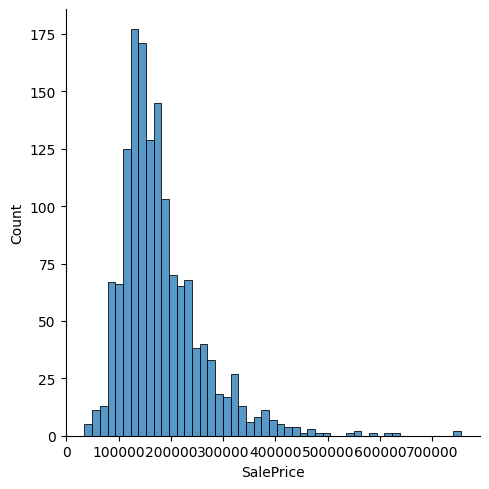

In [9]:
import seaborn as sns 
sns.displot(target)

In [10]:
log_tg = np.log(target)

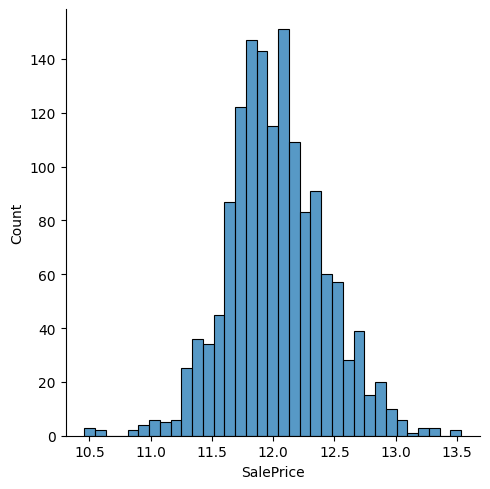

In [11]:
sns.displot(log_tg)

array([[<Axes: title={'center': 'SalesPrice'}>,
        <Axes: title={'center': 'Log_Prices'}>]], dtype=object)

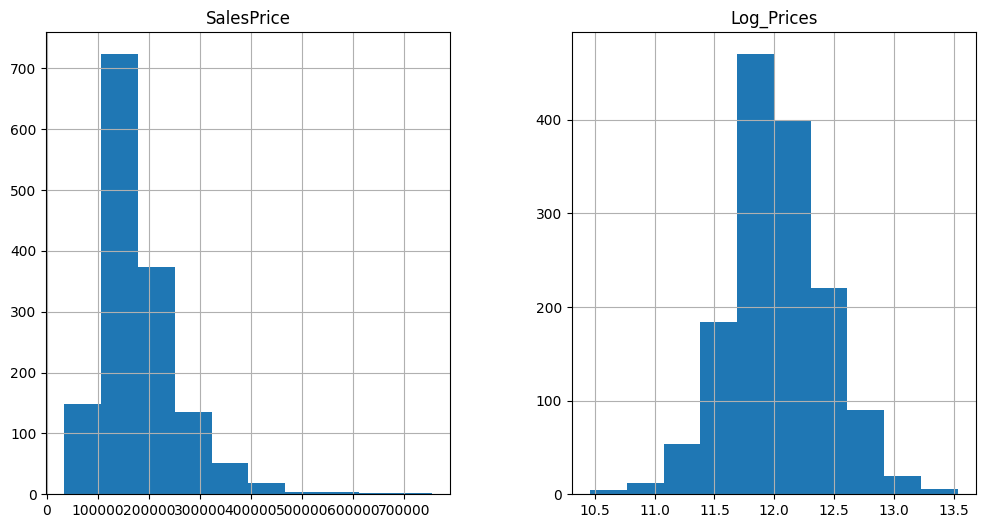

In [12]:
plt.rcParams['figure.figsize'] = (12.0, 6.0)
prices = pd.DataFrame({'SalesPrice' : df['SalePrice'], 'Log_Prices': log_tg})
prices.hist()

In [13]:
raw_data = df
df = df.drop(['SalePrice'],axis=1)
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal



## Data Cleaning & Preprocessing

In [14]:
df['MSSubClass'] = df['MSSubClass'].apply(str)

In [15]:
df['OverallCond'] = df['OverallCond'].astype(str)

In [16]:
df['YrSold'] = df['YrSold'].astype(str)

In [17]:
df['MoSold'] = df['MoSold'].astype(str)

In [18]:
df['TotalSf'] = df['1stFlrSF']+df['TotalBsmtSF']+df['2ndFlrSF']

## Feature Engineering

In [19]:
df = df.drop(['1stFlrSF'],axis=1)
df = df.drop(['2ndFlrSF'], axis=1)
df = df.drop(['TotalBsmtSF'], axis=1)
df = df.drop(['Id'],axis=1)

In [20]:
df.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,TotalSf
0,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,2566
1,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,2524
2,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,2706
3,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,2473
4,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,3343


In [21]:
cat_col = [col for col in df.columns.values if df[col].dtype == 'object']

In [22]:
df_cat = df[cat_col]
df_num = df.drop(cat_col, axis=1)

In [23]:
df_num.describe()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,LowQualFinSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,TotalSf
count,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,1460.000000,1460.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,70.049958,10516.828082,6.099315,1971.267808,1984.865753,103.685262,443.639726,46.549315,567.240411,5.844521,...,1.767123,472.980137,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,2567.048630
std,24.284752,9981.264932,1.382997,30.202904,20.645407,181.066207,456.098091,161.319273,441.866955,48.623081,...,0.747315,213.804841,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,821.714421
min,21.000000,1300.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,334.000000
25%,59.000000,7553.500000,5.000000,1954.000000,1967.000000,0.000000,0.000000,0.000000,223.000000,0.000000,...,1.000000,334.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2009.500000
50%,69.000000,9478.500000,6.000000,1973.000000,1994.000000,0.000000,383.500000,0.000000,477.500000,0.000000,...,2.000000,480.000000,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2474.000000
75%,80.000000,11601.500000,7.000000,2000.000000,2004.000000,166.000000,712.250000,0.000000,808.000000,0.000000,...,2.000000,576.000000,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3004.000000
max,313.000000,215245.000000,10.000000,2010.000000,2010.000000,1600.000000,5644.000000,1474.000000,2336.000000,572.000000,...,4.000000,1418.000000,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,11752.000000


In [24]:
df_cat.head()

,MSSubClass,MSZoning,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,...,GarageQual,GarageCond,PavedDrive,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition
0,60,RL,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,NaN,NaN,NaN,2,2008,WD,Normal
1,20,RL,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,...,TA,TA,Y,NaN,NaN,NaN,5,2007,WD,Normal
2,60,RL,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,...,TA,TA,Y,NaN,NaN,NaN,9,2008,WD,Normal
3,70,RL,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,...,TA,TA,Y,NaN,NaN,NaN,2,2006,WD,Abnorml
4,60,RL,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,...,TA,TA,Y,NaN,NaN,NaN,12,2008,WD,Normal


In [25]:
df_num = (df_num - df_num.mean()) / (df_num.max() - df_num.min())
df_num.describe()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,LowQualFinSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,TotalSf
count,1.201000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.452000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,...,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03,1.460000e+03
mean,-2.311039e-17,-3.193792e-18,2.250863e-17,2.320822e-16,1.546404e-15,-5.199392e-18,-3.650048e-18,1.596896e-18,-1.406789e-17,-4.562560e-19,...,1.216683e-17,-4.866731e-18,4.258390e-18,3.650048e-18,3.041707e-18,1.520853e-19,6.007371e-18,-9.125121e-19,1.901067e-19,-1.779399e-17
std,8.316696e-02,4.665342e-02,1.536663e-01,2.188616e-01,3.440901e-01,1.131664e-01,8.081114e-02,1.094432e-01,1.891554e-01,8.500539e-02,...,1.868288e-01,1.507792e-01,1.462530e-01,1.211262e-01,1.107231e-01,5.771128e-02,1.161613e-01,5.444080e-02,3.200794e-02,7.196658e-02
min,-1.679793e-01,-4.308036e-02,-5.665906e-01,-7.193319e-01,-5.810959e-01,-6.480329e-02,-7.860378e-02,-3.158027e-02,-2.428255e-01,-1.021769e-02,...,-4.417808e-01,-3.335544e-01,-1.099703e-01,-8.530215e-02,-3.977194e-02,-6.711789e-03,-3.137700e-02,-3.738352e-03,-2.805745e-03,-1.955727e-01
25%,-3.784232e-02,-1.385089e-02,-1.221461e-01,-1.251290e-01,-2.977626e-01,-6.480329e-02,-7.860378e-02,-3.158027e-02,-1.473632e-01,-1.021769e-02,...,-1.917808e-01,-9.765877e-02,-1.099703e-01,-8.530215e-02,-3.977194e-02,-6.711789e-03,-3.137700e-02,-3.738352e-03,-2.805745e-03,-4.883067e-02
50%,-3.595748e-03,-4.853248e-03,-1.103501e-02,1.255211e-02,1.522374e-01,-6.480329e-02,-1.065551e-02,-3.158027e-02,-3.841627e-02,-1.021769e-02,...,5.821918e-02,4.950538e-03,-1.099703e-01,-3.959831e-02,-3.977194e-02,-6.711789e-03,-3.137700e-02,-3.738352e-03,-2.805745e-03,-8.149293e-03
75%,3.407549e-02,5.069863e-03,1.000761e-01,2.082043e-01,3.189041e-01,3.894671e-02,4.759218e-02,-3.158027e-02,1.030649e-01,-1.021769e-02,...,5.821918e-02,7.265153e-02,8.606240e-02,3.901230e-02,-3.977194e-02,-6.711789e-03,-3.137700e-02,-3.738352e-03,-2.805745e-03,3.826864e-02
max,8.320207e-01,9.569196e-01,4.334094e-01,2.806681e-01,4.189041e-01,9.351967e-01,9.213962e-01,9.684197e-01,7.571745e-01,9.897823e-01,...,5.582192e-01,6.664456e-01,8.900297e-01,9.146979e-01,9.602281e-01,9.932882e-01,9.686230e-01,9.962616e-01,9.971943e-01,8.044273e-01


<Axes: >

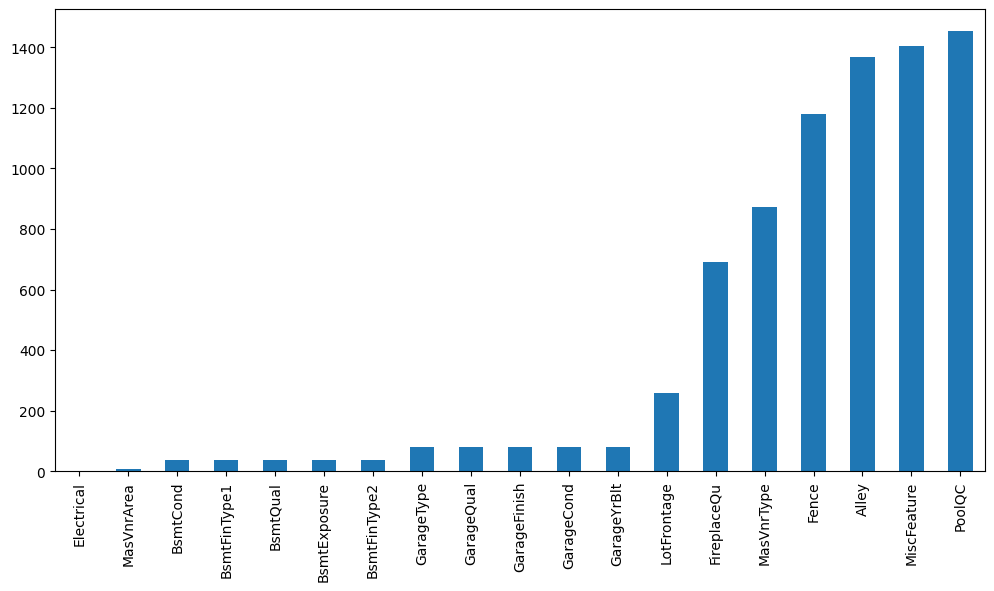

In [26]:
null_values = df.isnull().sum()
null_values = null_values[null_values>0]
null_values.sort_values(inplace=True)
null_values.plot.bar()

In [27]:
total = df.isnull().sum().sort_values(ascending=False)
percent = (df.isnull().sum()/df.isnull().count()).sort_values(ascending=False)
missing_data = pd.concat([total, percent], axis=1, keys=['Total', 'Percent'])
missing_data.head(15)

,Total,Percent
PoolQC,1453,0.995205
MiscFeature,1406,0.963014
Alley,1369,0.937671
Fence,1179,0.807534
MasVnrType,872,0.597260
FireplaceQu,690,0.472603
LotFrontage,259,0.177397
GarageQual,81,0.055479
GarageFinish,81,0.055479
GarageType,81,0.055479


In [28]:
data_len = df_num.shape[0]
print(data_len)
for col in df_num.columns.values:
    missing_values = df_num[col].isnull().sum()

    if missing_values > 260:
        df_num = df_num.drop(col,axis=1)
    else:
        df_num[col] = df_num[col].fillna(df_num[col].median())

1460


In [29]:
data_len = df_cat.shape[0]
print(data_len)
for col in df_cat.columns.values:
    missing_values = df_cat[col].isnull().sum()

    if missing_values > 260:
        print(f'dropping column: {col}')
        df_cat = df_cat.drop(col,axis=1)
    else:
        pass

1460
dropping column: Alley
dropping column: MasVnrType
dropping column: FireplaceQu
dropping column: PoolQC
dropping column: Fence
dropping column: MiscFeature


In [30]:
df_cat.describe()

,MSSubClass,MSZoning,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,...,Functional,GarageType,GarageFinish,GarageQual,GarageCond,PavedDrive,MoSold,YrSold,SaleType,SaleCondition
count,1460,1460,1460,1460,1460,1460,1460,1460,1460,1460,...,1460,1379,1379,1379,1379,1460,1460,1460,1460,1460
unique,15,5,2,4,4,2,5,3,25,9,...,7,6,3,5,5,3,12,5,9,6
top,20,RL,Pave,Reg,Lvl,AllPub,Inside,Gtl,NAmes,Norm,...,Typ,Attchd,Unf,TA,TA,Y,6,2009,WD,Normal
freq,536,1151,1454,925,1311,1459,1052,1382,225,1260,...,1360,870,605,1311,1326,1340,253,338,1267,1198


In [31]:
df_cat.columns

Index(['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'OverallCond', 'RoofStyle',
       'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual',
       'GarageCond', 'PavedDrive', 'MoSold', 'YrSold', 'SaleType',
       'SaleCondition'],
      dtype='object')

In [32]:
df_cat_dummies = pd.get_dummies(df_cat,drop_first=True)

In [33]:
df_cat_dummies.head(9)

,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
0,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
1,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
2,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
5,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,True,False
6,False,False,False,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
7,False,False,False,False,False,False,False,False,True,False,...,False,False,False,False,True,False,False,False,True,False
8,False,False,False,False,False,False,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False


In [34]:
print(f'Numerical Features: {len(df_num.columns)}')
print(f'Categorical Features: {len(df_cat_dummies.columns)}')

Numerical Features: 30
Categorical Features: 230


In [35]:
df_num.head()

,LotFrontage,LotArea,OverallQual,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,LowQualFinSF,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,TotalSf
0,-0.017294,-0.009661,0.100076,0.229943,0.302237,0.057697,0.046485,-0.03158,-0.178613,-0.010218,...,0.058219,0.052905,-0.109970,0.026215,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,-0.000092
1,0.034075,-0.004285,-0.011035,0.034291,-0.147763,-0.064803,0.094678,-0.03158,-0.121250,-0.010218,...,0.058219,-0.009154,0.237754,-0.085302,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,-0.003770
2,-0.007020,0.003427,0.100076,0.215451,0.285571,0.036447,0.007505,-0.03158,-0.057038,-0.010218,...,0.058219,0.095219,-0.109970,-0.008520,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,0.012170
3,-0.034418,-0.004519,0.100076,-0.407738,-0.247763,-0.064803,-0.040333,-0.03158,-0.011661,-0.010218,...,0.308219,0.119196,-0.109970,-0.021317,0.452982,-0.006712,-0.031377,-0.003738,-0.002806,-0.008237
4,0.047774,0.017496,0.211187,0.208204,0.252237,0.153947,0.037449,-0.03158,-0.033065,-0.010218,...,0.308219,0.256008,0.114067,0.068263,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,0.067959


In [36]:
df_new = pd.concat([df_cat_dummies,df_num],axis=1)

In [37]:
df_new.head()

,MSSubClass_160,MSSubClass_180,MSSubClass_190,MSSubClass_20,MSSubClass_30,MSSubClass_40,MSSubClass_45,MSSubClass_50,MSSubClass_60,MSSubClass_70,...,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,TotalSf
0,False,False,False,False,False,False,False,False,True,False,...,0.058219,0.052905,-0.109970,0.026215,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,-0.000092
1,False,False,False,True,False,False,False,False,False,False,...,0.058219,-0.009154,0.237754,-0.085302,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,-0.003770
2,False,False,False,False,False,False,False,False,True,False,...,0.058219,0.095219,-0.109970,-0.008520,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,0.012170
3,False,False,False,False,False,False,False,False,False,True,...,0.308219,0.119196,-0.109970,-0.021317,0.452982,-0.006712,-0.031377,-0.003738,-0.002806,-0.008237
4,False,False,False,False,False,False,False,False,True,False,...,0.308219,0.256008,0.114067,0.068263,-0.039772,-0.006712,-0.031377,-0.003738,-0.002806,0.067959


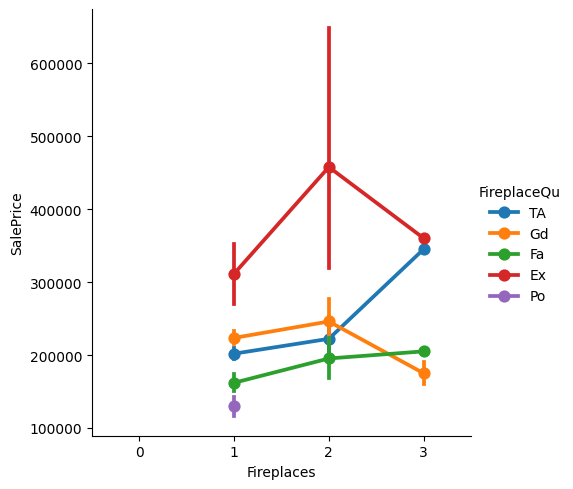

In [38]:
sns.catplot(x="Fireplaces", 
            y="SalePrice", 
            data=raw_data, 
            hue="FireplaceQu", 
            kind="point")

In [39]:
FireplaceQu = raw_data["FireplaceQu"].fillna('None')
pd.crosstab(raw_data["Fireplaces"], FireplaceQu)

FireplaceQu,Ex,Fa,Gd,None,Po,TA
Fireplaces,,,,,,
0,0,0,0,690,0,0
1,19,28,324,0,20,259
2,4,4,54,0,0,53
3,1,1,2,0,0,1


<Axes: xlabel='OverallQual', ylabel='SalePrice'>

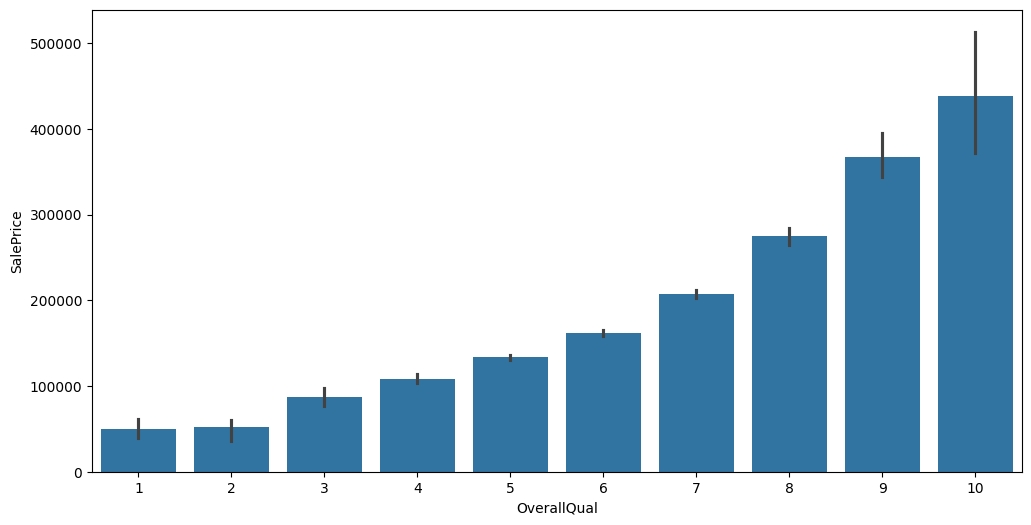

In [40]:
sns.barplot(x=raw_data.OverallQual,y=raw_data.SalePrice)

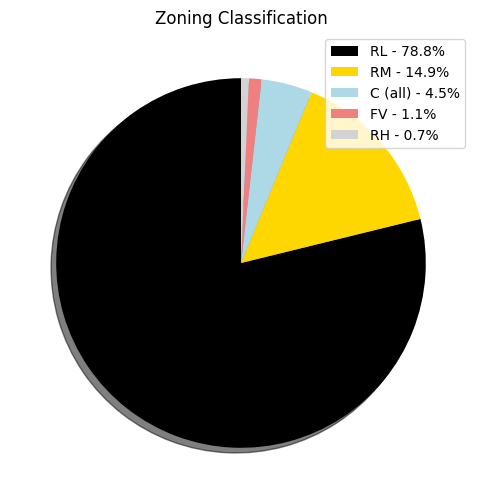

In [41]:
import matplotlib.pyplot as plt

# Pie chart for zoning classification
labels = raw_data["MSZoning"].unique()
sizes = raw_data["MSZoning"].value_counts().values
explode = (0, 0, 0, 0, 0)  # no slice exploded
percent = 100. * sizes / sum(sizes)

# Format labels with percentages
labels = ['{0} - {1:1.1f}%'.format(i, j) for i, j in zip(labels, percent)]

colors = ['black', 'gold', 'lightblue', 'lightcoral', 'lightgray']

patches, texts = plt.pie(
    sizes,
    colors=colors,
    explode=explode,
    shadow=True,
    startangle=90
)

plt.legend(patches, labels, loc="best")
plt.title("Zoning Classification")
plt.show()


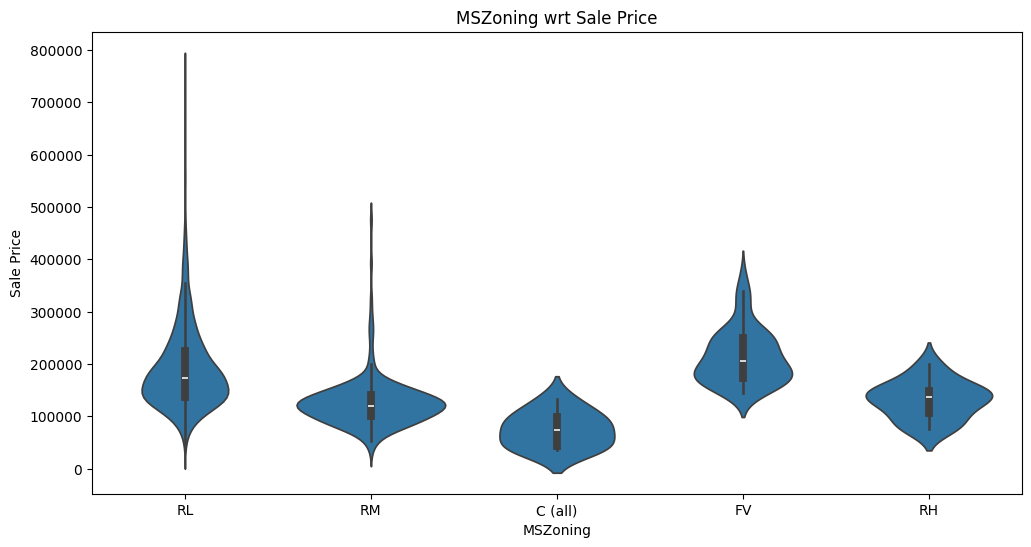

In [42]:
sns.violinplot(x="MSZoning", 
               y="SalePrice", 
               data=raw_data)

plt.title("MSZoning wrt Sale Price")
plt.xlabel("MSZoning")
plt.ylabel("Sale Price")
plt.show()

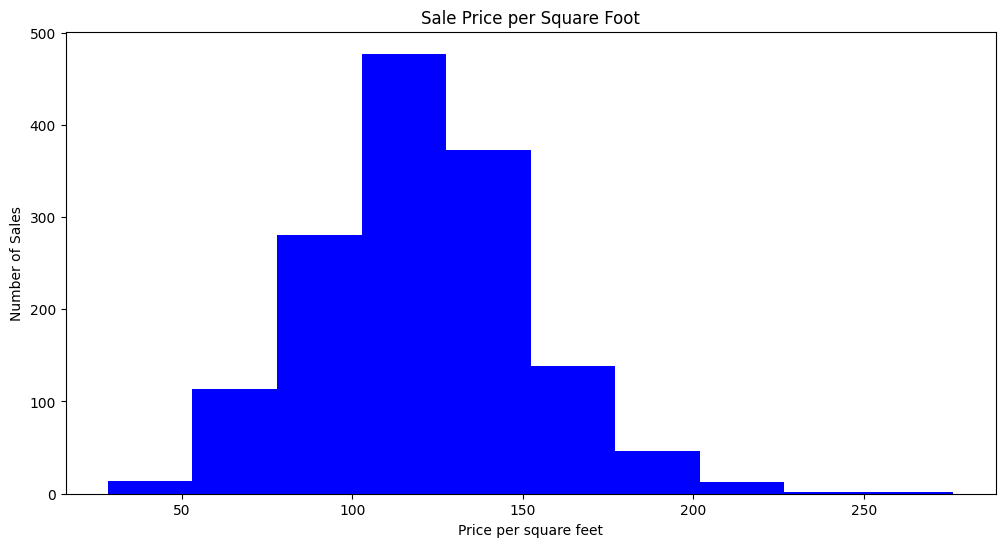

In [43]:
SalePriceSF = raw_data["SalePrice"] / raw_data["GrLivArea"]

plt.hist(SalePriceSF, color="blue")
plt.title("Sale Price per Square Foot")
plt.ylabel("Number of Sales")
plt.xlabel("Price per square feet")
plt.show()

Text(0.5, 1.0, 'Construction Age vs Sale Price per Square Foot')

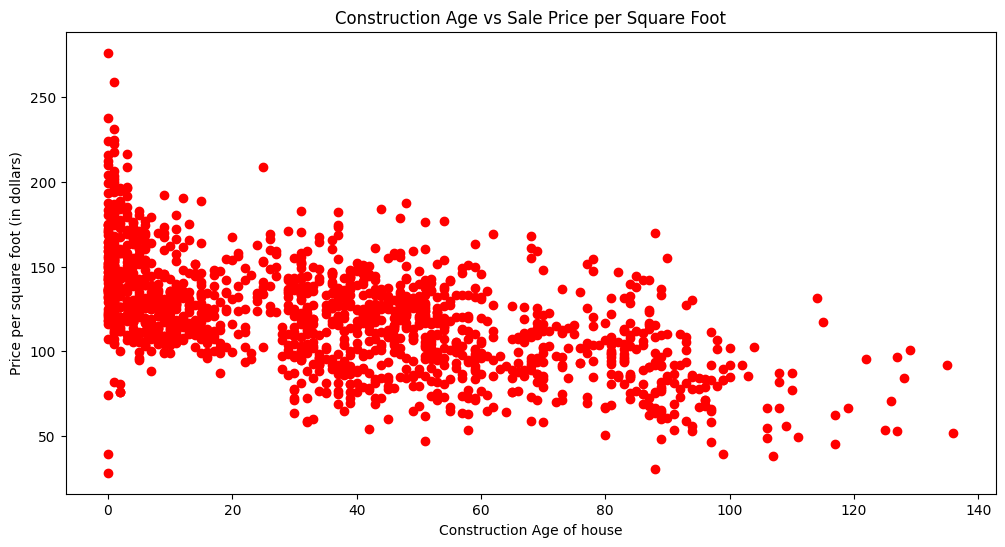

In [44]:
ConstructionAge = raw_data["YrSold"] - raw_data["YearBuilt"]
plt.scatter(ConstructionAge, SalePriceSF, color="red")
plt.ylabel("Price per square foot (in dollars)")
plt.xlabel("Construction Age of house")
plt.title("Construction Age vs Sale Price per Square Foot")

Text(0.5, 1.0, 'Sales Prices vs Full BathRoom')

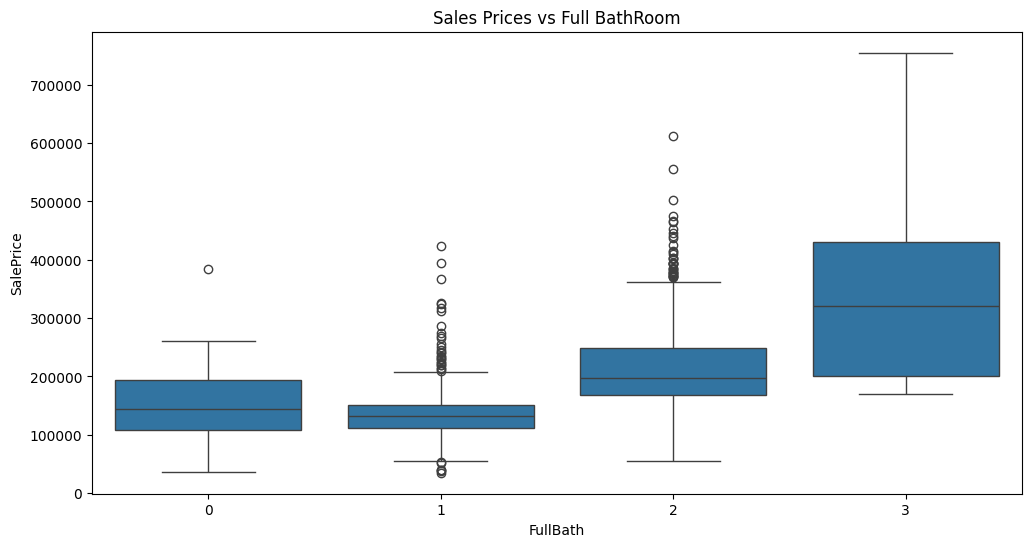

In [45]:
sns.boxplot(x=raw_data['FullBath'],y=raw_data['SalePrice'])
plt.title('Sales Prices vs Full BathRoom')

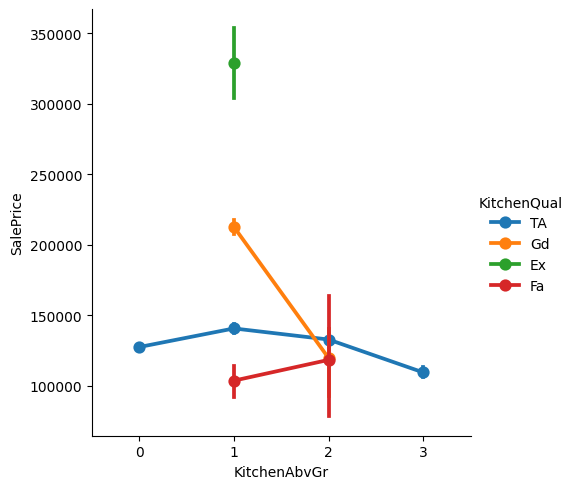

In [46]:
sns.catplot(x="KitchenAbvGr", 
            y="SalePrice", 
            data=raw_data, 
            hue="KitchenQual",
            kind="point")

<Axes: >

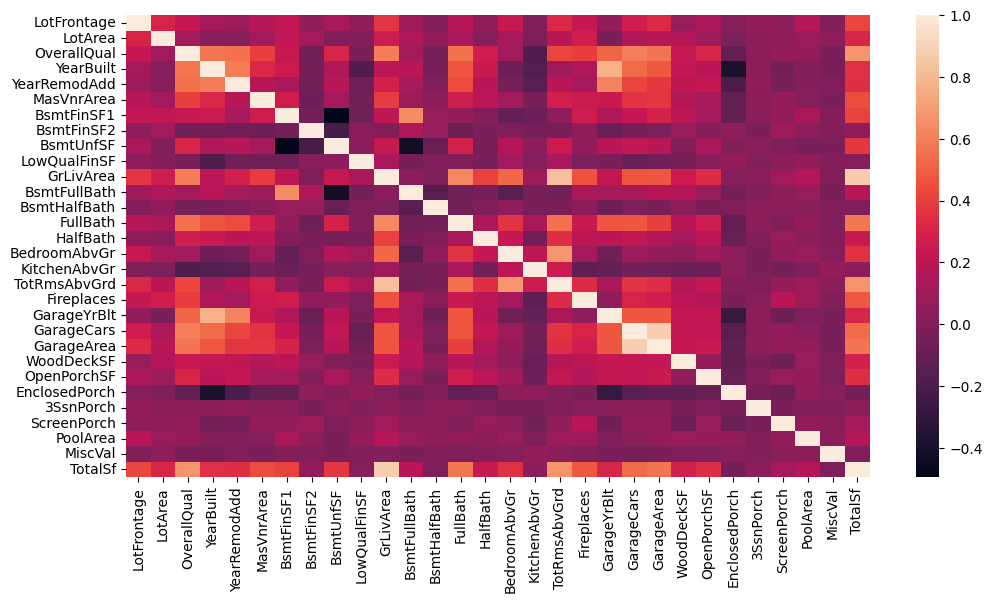

In [47]:
corr = df_num.corr()
sns.heatmap(corr)

## Train_Test_Split

In [48]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df_new,log_tg,test_size=0.3,random_state=0)

In [49]:
x_train.shape, y_train.shape , x_test.shape, y_test.shape

((1022, 260), (1022,), (438, 260), (438,))


## Model Training

In [50]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](260,)","[-0.08,-0.02,-0.02,..., 0.19, 0.06, 0.67]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](260,)","['MSSubClass_160','MSSubClass_180','MSSubClass_190',...,'PoolArea', 'MiscVal','TotalSf']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,11.45
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,260
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,249


In [51]:
pred = lr.predict(x_test)

## Model Evaluation

In [52]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [53]:
print("R² Score:", r2_score(y_test,pred))
print("Mean Squared Error:", mean_squared_error(y_test,pred))
print("Mean Absolute Error:", mean_absolute_error(y_test,pred))

R² Score: 0.7211854539034697
Mean Squared Error: 0.04307995194002554
Mean Absolute Error: 0.09974629110529722


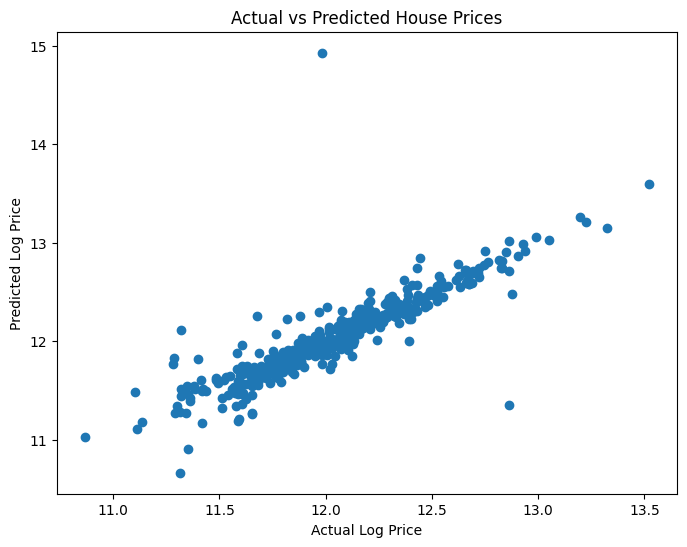

In [54]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, pred)
plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

## Results

The Linear Regression model was trained on the processed housing dataset and evaluated on unseen test data. Performance was measured using R² Score, Mean Squared Error (MSE), and Mean Absolute Error (MAE). The Actual vs Predicted plot indicates that the model captures the general trend of house prices reasonably well.

## Conclusion

A Linear Regression model was developed to predict house prices using the Ames Housing dataset.

Key steps included:
- Handling missing values
- Feature engineering
- One-hot encoding categorical features
- Feature scaling
- Model training and evaluation

The model achieved satisfactory performance and demonstrated how preprocessing and feature engineering significantly influence prediction quality.